In [8]:
import osmnx as ox
import networkx as nx
from osmnx.features import features_from_bbox
import geopandas as gpd
from geometric_utilities import *
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
# 1) define your area of interest in lon/lat
west, south, east, north = 9.2257, 45.47162, 9.23768, 45.48537
bbox = (west, south, east, north)

# ────────────────
# 2) street network (all modes: drive+walk+bike…)
# ────────────────
G = ox.graph.graph_from_bbox(
    bbox=bbox,
    network_type="all",             # drive, walk, bike, all_public, etc.
)  # multiDiGraph of every way in bbox :contentReference[oaicite:0]{index=0}
nodes, edges = ox.graph_to_gdfs(G)

# ────────────────
# 3) vector features via Overpass
# ────────────────
# a) building footprints (+ any height/levels tags)
tags_buildings = {"building": True}
gdf_buildings = features_from_bbox(bbox, tags_buildings)  
# returns a GeoDataFrame multi-indexed by element type & OSM ID :contentReference[oaicite:1]{index=1}

# b) parks & town squares
tags_parks = {
    "leisure": ["park", "garden"],
    "amenity": ["town_square"]
}
gdf_parks = features_from_bbox(bbox, tags_parks)

# c) land-use areas (residential, commercial, industrial…)
tags_landuse = {"landuse": True}
gdf_landuse = features_from_bbox(bbox, tags_landuse)

# d) water bodies & waterways
tags_water = {"natural": ["water", "wetland"], "waterway": True}
gdf_water = features_from_bbox(bbox, tags_water)

# e) points of interest (amenities, shops, tourism…)
tags_pois = {"amenity": True, "shop": True, "tourism": True}
gdf_pois = features_from_bbox(bbox, tags_pois)

Street segments: 4942
Buildings: 1137
Parks/squares: 32


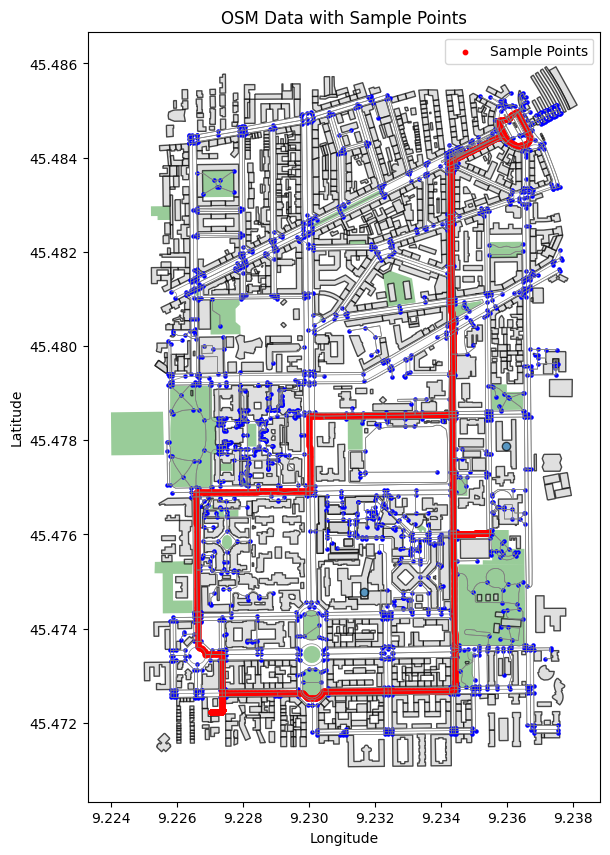

In [10]:
# ────────────────
# 4) quick inspection / plotting
# ────────────────

print("Street segments:", len(edges))
print("Buildings:", len(gdf_buildings))
print("Parks/squares:", len(gdf_parks))

# example plot
ax = edges.plot(linewidth=0.5, color="gray", figsize=(10, 10))
gdf_parks.plot(ax=ax, facecolor="green", alpha=0.4)
gdf_buildings.plot(ax=ax, facecolor="lightgray", edgecolor="black", alpha=0.7)
nodes.plot(ax=ax, color="blue", markersize=5)

# plot df.x and df.y in the same plot
df = pd.read_csv('../data/processed_data/S1CO2-approx-coordinates.csv')
ax.scatter(df.x, df.y, color='red', s=10, label='Sample Points')
ax.set_title("OSM Data with Sample Points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.show()


In [11]:
df['close2park'] = df.apply(lambda row: is_close_to_park(gdf_parks, Point(row.x, row.y)), axis=1).astype(int)

In [12]:
nodes

,y,x,street_count,junction,highway,railway,geometry
osmid,,,,,,,
25543525,45.472660,9.230426,3,NaN,NaN,NaN,POINT (9.23043 45.47266)
25543649,45.473430,9.226358,3,NaN,NaN,NaN,POINT (9.22636 45.47343)
25543872,45.472626,9.226626,4,NaN,NaN,NaN,POINT (9.22663 45.47263)
25543897,45.472657,9.229758,3,NaN,NaN,NaN,POINT (9.22976 45.47266)
25543899,45.472634,9.227373,4,NaN,NaN,NaN,POINT (9.22737 45.47263)
...,...,...,...,...,...,...,...
12046814147,45.484306,9.237115,3,NaN,NaN,NaN,POINT (9.23711 45.48431)
12046814151,45.485017,9.236441,4,NaN,NaN,NaN,POINT (9.23644 45.48502)
12046814163,45.484915,9.236521,3,NaN,NaN,NaN,POINT (9.23652 45.48492)


In [13]:
df

,CO2,signal,location,regime,x,y,close2park
0,1030.695381,0.0,A,static,9.227043,45.472225,0
1,1052.020894,0.0,A,static,9.227043,45.472225,0
2,1071.102377,0.0,A,static,9.227043,45.472225,0
3,1087.935351,0.0,A,static,9.227043,45.472225,0
4,1102.533810,0.0,A,static,9.227043,45.472225,0
...,...,...,...,...,...,...,...
5841,90.451462,0.0,GH,dynamic,9.227380,45.472259,0
5842,66.961660,0.0,GH,dynamic,9.227380,45.472262,0
5843,44.771347,0.0,GH,dynamic,9.227380,45.472265,0
5844,23.962254,0.0,GH,dynamic,9.227380,45.472268,0
